In [21]:
#importacion de librerias necesarias
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.tree import plot_tree
import joblib

# Dataset del Titanic: Descripción de Columnas

Este conjunto de datos se utiliza comúnmente en ciencia de datos para predecir la supervivencia de los pasajeros del RMS Titanic. A continuación se detalla el significado de cada columna:

| Columna | Descripción | Valores posibles / Ejemplos |
| :--- | :--- | :--- |
| **PassengerId** | Identificador único secuencial para cada pasajero. | `1`, `2`, `3`... |
| **Survived** | Indica si el pasajero sobrevivió o no. *(Variable objetivo)* | `0` = No, `1` = Sí |
| **Pclass** | Clase del boleto (indicador de estatus socioeconómico). | `1` = 1.ª clase, `2` = 2.ª clase, `3` = 3.ª clase |
| **Name** | Nombre completo del pasajero (incluye título social). | "Braund, Mr. Owen Harris" |
| **Sex** | Género del pasajero. | `male` (hombre), `female` (mujer) |
| **Age** | Edad del pasajero en años. | Fraccionaria si es menor de 1 año |
| **SibSp** | Número de hermanos (*siblings*) o cónyuge (*spouse*) a bordo. | `0`, `1`, `2`... |
| **Parch** | Número de padres (*parents*) o hijos (*children*) a bordo. | `0`, `1`, `2`... |
| **Ticket** | Número del boleto de viaje. | "A/5 21171", "PC 17599" |
| **Fare** | Tarifa o precio pagado por el boleto. | Valor numérico (ej. `7.25`) |
| **Cabin** | Número de la cabina asignada al pasajero. | "C85", "C123" (vacío si no tenía) |
| **Embarked** | Puerto donde el pasajero abordó el barco. | **C** = Cherbourg, **Q** = Queenstown, **S** = Southampton |


In [22]:
url_github = "https://raw.githubusercontent.com/JunnyCueva/Mineria_de_datos/refs/heads/main/Titanic-Dataset.csv"
# Leer el archivo CSV directamente desde la web
df = pd.read_csv(url_github)

# Verificar la carga exitosa mostrando las primeras filas y dimensiones
print("Archivo cargado con éxito desde GitHub")

Archivo cargado con éxito desde GitHub


In [23]:
df.head()

,Name,Sex,Age,SibSp,Parch,Embarked,Ticket,Fare,Cabin,PassengerId,Pclass,Survived
0,"Braund, Mr. Owen Harris",male,22.0,1,0,S,A/5 21171,7.2500,NaN,1,3,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,C,PC 17599,71.2833,C85,2,1,1
2,"Heikkinen, Miss. Laina",female,26.0,0,0,S,STON/O2. 3101282,7.9250,NaN,3,3,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,S,113803,53.1000,C123,4,1,1
4,"Allen, Mr. William Henry",male,35.0,0,0,S,373450,8.0500,NaN,5,3,0


In [24]:
df.describe()

,Age,SibSp,Parch,Fare,PassengerId,Pclass,Survived
count,714.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,29.699118,0.523008,0.381594,32.204208,446.000000,2.308642,0.383838
std,14.526497,1.102743,0.806057,49.693429,257.353842,0.836071,0.486592
min,0.420000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,20.125000,0.000000,0.000000,7.910400,223.500000,2.000000,0.000000
50%,28.000000,0.000000,0.000000,14.454200,446.000000,3.000000,0.000000
75%,38.000000,1.000000,0.000000,31.000000,668.500000,3.000000,1.000000
max,80.000000,8.000000,6.000000,512.329200,891.000000,3.000000,1.000000


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         891 non-null    object 
 1   Sex          891 non-null    object 
 2   Age          714 non-null    float64
 3   SibSp        891 non-null    int64  
 4   Parch        891 non-null    int64  
 5   Embarked     889 non-null    object 
 6   Ticket       891 non-null    object 
 7   Fare         891 non-null    float64
 8   Cabin        204 non-null    object 
 9   PassengerId  891 non-null    int64  
 10  Pclass       891 non-null    int64  
 11  Survived     891 non-null    int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [26]:
# 2. Limpieza de datos (Tratamiento de nulos y selección de variables)
# Seleccionamos variables principales: Pclass, Sex, Age, SibSp, Parch, Fare, Survived
cols_to_use = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Survived']
df_model = df[cols_to_use].copy()

# Tratamiento de nulos en Edad (imputación por la mediana)
df_model['Age'] = df_model['Age'].fillna(df_model['Age'].median())
# Tratamiento de nulos en Fare si los hubiera
df_model['Fare'] = df_model['Fare'].fillna(df_model['Fare'].median())

# Codificación de variables categóricas (Sex: male/female a numérico)
df_model['Sex'] = df_model['Sex'].map({'male': 0, 'female': 1})

# 3. Ingeniería de Características (Feature Engineering)
# Variable derivada 1: Tamaño de la familia a bordo
df_model['Family_Size'] = df_model['SibSp'] + df_model['Parch'] + 1
# Variable derivada 2: Costo por miembro de familia (Tarifa per cápita)
df_model['Fare_Per_Person'] = df_model['Fare'] / df_model['Family_Size']

# Definir características (X) y variable objetivo (y)
X = df_model.drop(columns=['Survived'])
y = df_model['Survived']

# 4. División de datos: 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Escalado de variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Implementación de 3 técnicas de minería de datos (Clasificación)
# Modelo 1: Árbol de Decisión
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)

# Modelo 2: Regresión Logística
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Modelo 3: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)

print("Modelos entrenados correctamente.")

Modelos entrenados correctamente.


In [40]:
df.head()

,Name,Sex,Age,SibSp,Parch,Embarked,Ticket,Fare,Cabin,PassengerId,Pclass,Survived
0,"Braund, Mr. Owen Harris",male,22.0,1,0,S,A/5 21171,7.2500,NaN,1,3,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,C,PC 17599,71.2833,C85,2,1,1
2,"Heikkinen, Miss. Laina",female,26.0,0,0,S,STON/O2. 3101282,7.9250,NaN,3,3,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,S,113803,53.1000,C123,4,1,1
4,"Allen, Mr. William Henry",male,35.0,0,0,S,373450,8.0500,NaN,5,3,0


In [27]:
df.describe()

,Age,SibSp,Parch,Fare,PassengerId,Pclass,Survived
count,714.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,29.699118,0.523008,0.381594,32.204208,446.000000,2.308642,0.383838
std,14.526497,1.102743,0.806057,49.693429,257.353842,0.836071,0.486592
min,0.420000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,20.125000,0.000000,0.000000,7.910400,223.500000,2.000000,0.000000
50%,28.000000,0.000000,0.000000,14.454200,446.000000,3.000000,0.000000
75%,38.000000,1.000000,0.000000,31.000000,668.500000,3.000000,1.000000
max,80.000000,8.000000,6.000000,512.329200,891.000000,3.000000,1.000000


In [28]:
# Evaluación en el conjunto de prueba
models = {
    "Árbol de Decisión": tree_model,
    "Regresión Logística": log_reg,
    "Random Forest": rf_model
}

for name, model in models.items():
    if name == "Regresión Logística":
        preds = model.predict(X_test_scaled)
        proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        preds = model.predict(X_test)
        proba = model.predict_proba(X_test)[:, 1]
        
    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, proba)
    print(f"--- {name} ---")
    print(f"Exactitud (Accuracy): {acc:.4f}")
    print(f"AUC-ROC: {auc:.4f}\n")

# Validación Cruzada (5-Fold Cross-Validation) Random forest
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')
print(f"Validación Cruzada (Random Forest - 5 Particiones): Promedio Acc = {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

#Validacion Cruzada Arbol de decision
cv_tree = cross_val_score(tree_model, X, y, cv=5, scoring='accuracy')
print(f"Validación Cruzada (Árbol de Decisión - 5 Particiones): Promedio Acc = {cv_tree.mean():.4f} (+/- {cv_tree.std():.4f})")

#Validacion Cruzada Regresion Logistica
# Crear un pipeline que escale y luego aplique la Regresión Logística
log_reg_pipeline = make_pipeline(
    StandardScaler(), 
    LogisticRegression(max_iter=1000, random_state=42)
)

cv_logreg = cross_val_score(log_reg_pipeline, X, y, cv=5, scoring='accuracy')
print(f"Validación Cruzada (Regresión Logística - 5 Particiones): Promedio Acc = {cv_logreg.mean():.4f} (+/- {cv_logreg.std():.4f})")

--- Árbol de Decisión ---
Exactitud (Accuracy): 0.8212
AUC-ROC: 0.8674

--- Regresión Logística ---
Exactitud (Accuracy): 0.7989
AUC-ROC: 0.8788

--- Random Forest ---
Exactitud (Accuracy): 0.8045
AUC-ROC: 0.9011

Validación Cruzada (Random Forest - 5 Particiones): Promedio Acc = 0.8238 (+/- 0.0235)
Validación Cruzada (Árbol de Decisión - 5 Particiones): Promedio Acc = 0.8059 (+/- 0.0309)
Validación Cruzada (Regresión Logística - 5 Particiones): Promedio Acc = 0.7834 (+/- 0.0184)


**GRAFICAS ESTADÍSTICAS**

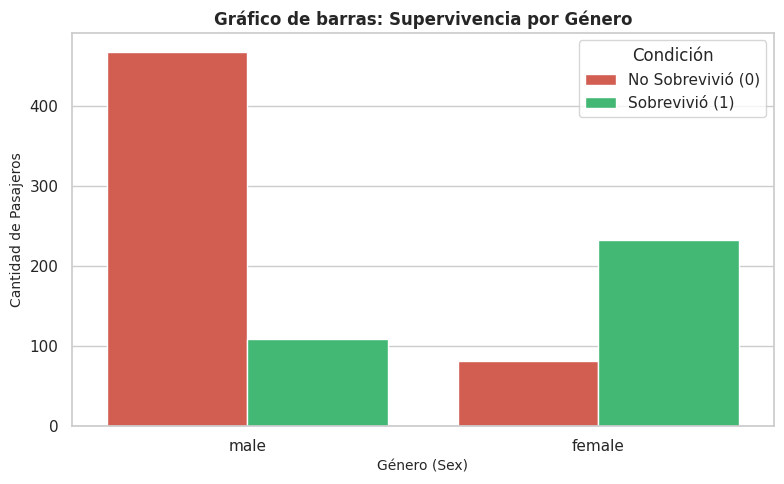

In [29]:
# ==========================================
# GRÁFICO 1: Supervivencia por Género
# ==========================================
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df, x='Sex', hue='Survived', palette=['#e74c3c', '#2ecc71']
)
plt.title(
    'Gráfico de barras: Supervivencia por Género',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Género (Sex)', fontsize=10)
plt.ylabel('Cantidad de Pasajeros', fontsize=10)
plt.legend(
    title='Condición',
    labels=['No Sobrevivió (0)', 'Sobrevivió (1)'],
    loc='upper right',
)
plt.tight_layout()
plt.show()

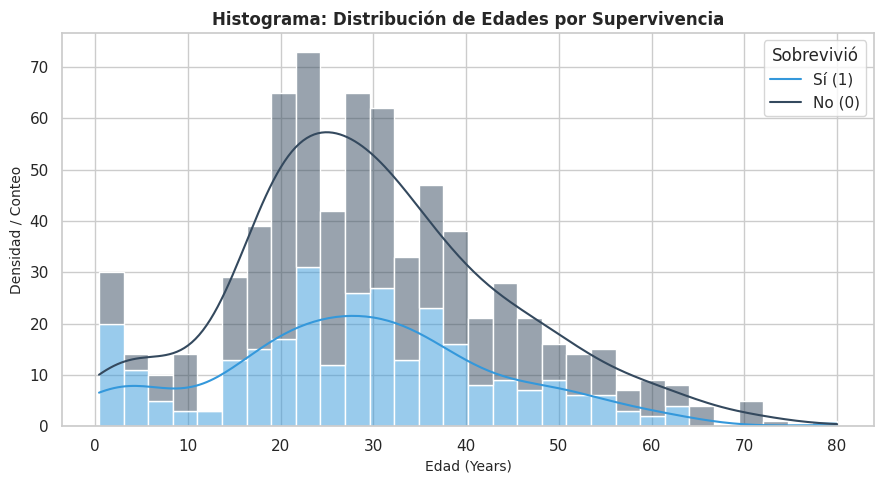

In [30]:
# ==========================================
# GRÁFICO 2: Histograma de Distribución de Edades
# ==========================================
plt.figure(figsize=(9, 5))
sns.histplot(
    data=df,
    x='Age',
    hue='Survived',
    multiple='stack',
    palette=['#34495e', '#3498db'],
    bins=30,
    kde=True,
)
plt.title(
    'Histograma: Distribución de Edades por Supervivencia',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Edad (Years)', fontsize=10)
plt.ylabel('Densidad / Conteo', fontsize=10)
plt.legend(title='Sobrevivió', labels=['Sí (1)', 'No (0)'])
plt.tight_layout()
plt.show()

/tmp/ipykernel_702/2194892818.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Pclass', y='Fare', palette='Set2')


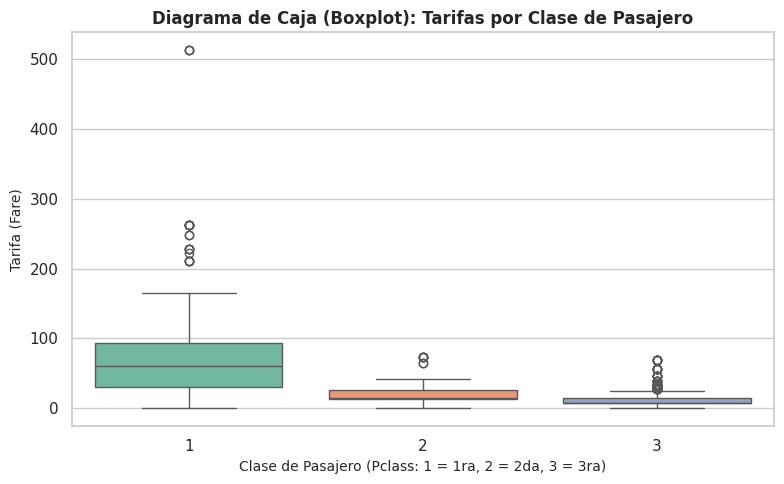

In [31]:
# ==========================================
# GRÁFICO 3: Diagrama de Caja (Boxplot) de Tarifas por Clase
# ==========================================
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Pclass', y='Fare', palette='Set2')
plt.title(
    'Diagrama de Caja (Boxplot): Tarifas por Clase de Pasajero',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Clase de Pasajero (Pclass: 1 = 1ra, 2 = 2da, 3 = 3ra)', fontsize=10)
plt.ylabel('Tarifa (Fare)', fontsize=10)
plt.tight_layout()
plt.show()

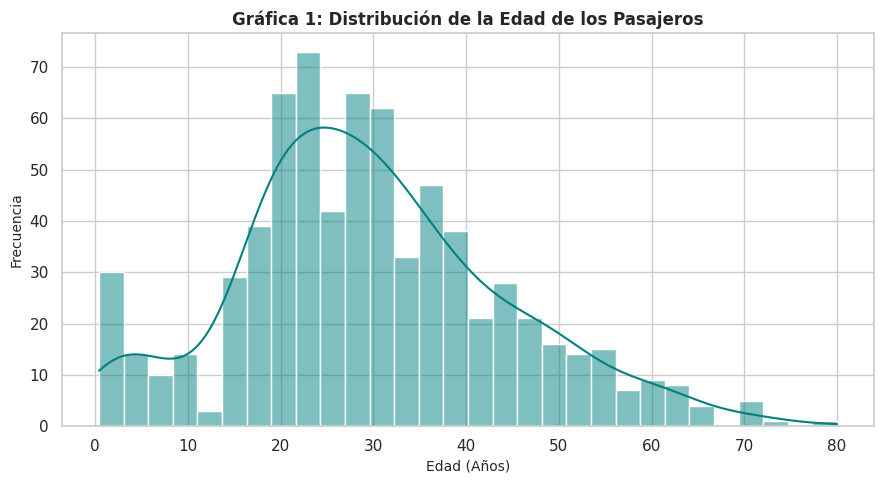

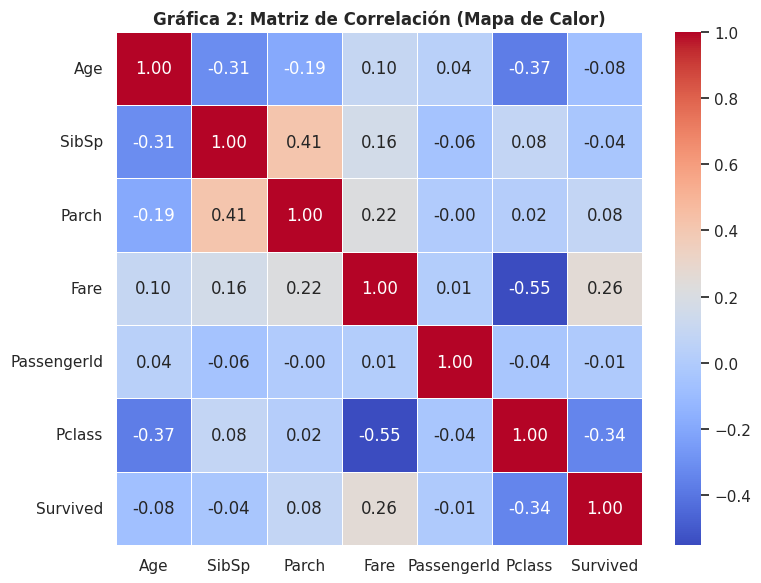

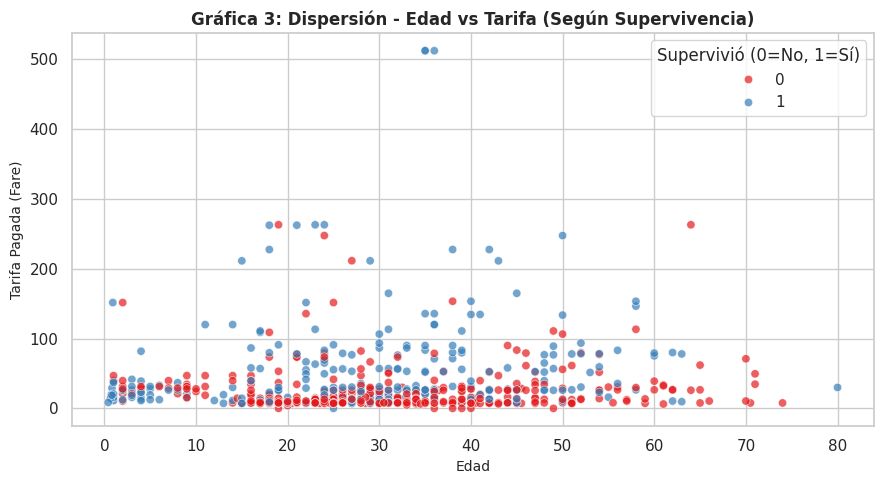

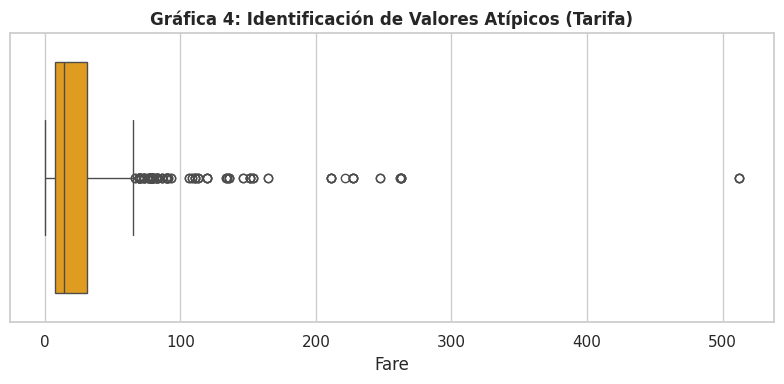

In [32]:
# Configuración estética de las gráficas
sns.set_theme(style="whitegrid")

# --- GRÁFICA 1: Histograma de Distribución ---
plt.figure(figsize=(9, 5))
sns.histplot(df['Age'].dropna(), kde=True, color='teal', bins=30)
plt.title('Gráfica 1: Distribución de la Edad de los Pasajeros', fontsize=12, fontweight='bold')
plt.xlabel('Edad (Años)', fontsize=10)
plt.ylabel('Frecuencia', fontsize=10)
plt.tight_layout()
plt.savefig('grafica_1_distribucion.png', dpi=300)
plt.show()

# --- GRÁFICA 2: Mapa de Calor de Correlación ---
plt.figure(figsize=(8, 6))
# Seleccionamos variables numéricas principales
numeric_cols = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Gráfica 2: Matriz de Correlación (Mapa de Calor)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('grafica_2_correlacion.png', dpi=300)
plt.show()

# --- GRÁFICA 3: Gráfico de Dispersión (Scatter Plot) ---
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='Age', y='Fare', hue='Survived', palette='Set1', alpha=0.7)
plt.title('Gráfica 3: Dispersión - Edad vs Tarifa (Según Supervivencia)', fontsize=12, fontweight='bold')
plt.xlabel('Edad', fontsize=10)
plt.ylabel('Tarifa Pagada (Fare)', fontsize=10)
plt.legend(title='Supervivió (0=No, 1=Sí)')
plt.tight_layout()
plt.savefig('grafica_3_dispersion.png', dpi=300)
plt.show()



plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Fare'], color='orange')
plt.title('Gráfica 4: Identificación de Valores Atípicos (Tarifa)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('grafica_4_outliers.png', dpi=300)
plt.show()

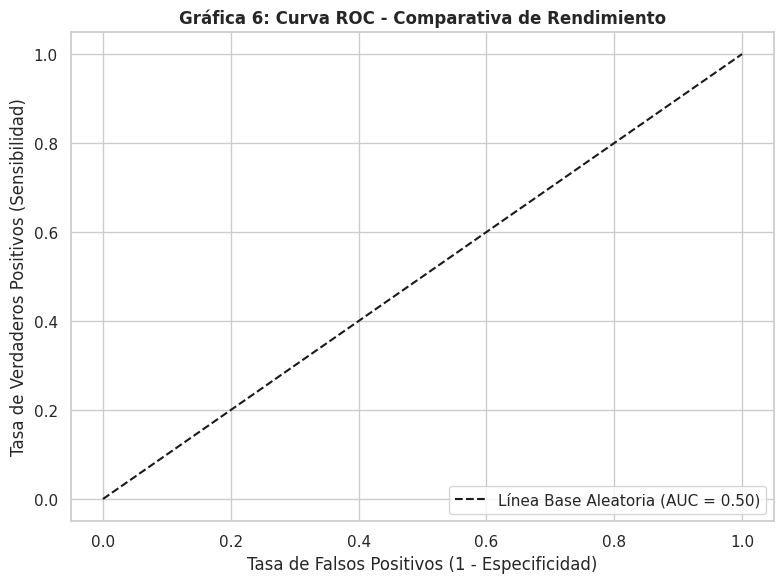

In [33]:
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Línea Base Aleatoria (AUC = 0.50)')
plt.title('Gráfica 6: Curva ROC - Comparativa de Rendimiento', fontsize=12, fontweight='bold')
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('grafica_6_curva_roc.png', dpi=300)
plt.show()

/tmp/ipykernel_702/477746823.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_imp_df, x='Importancia_Gini', y='Característica', palette='viridis')


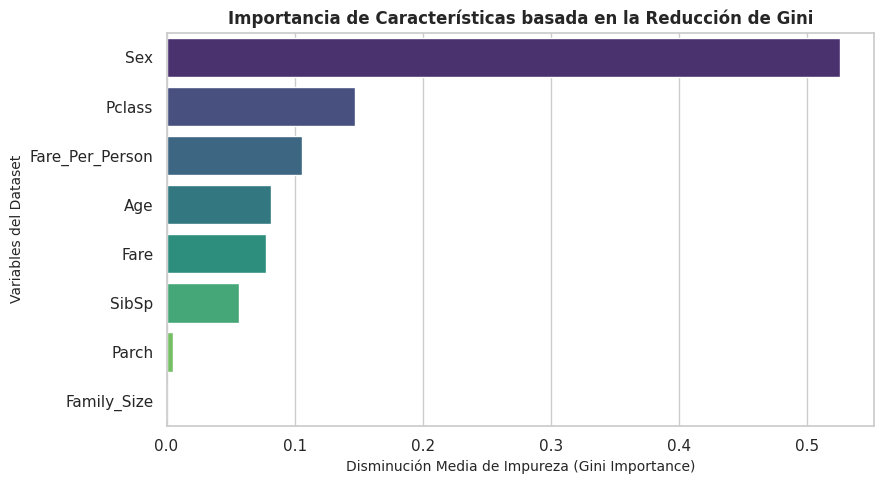

In [34]:
# Crear un DataFrame para ordenar la importancia
importances = tree_model.feature_importances_
features = X.columns
feature_imp_df = pd.DataFrame({'Característica': features, 'Importancia_Gini': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importancia_Gini', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=feature_imp_df, x='Importancia_Gini', y='Característica', palette='viridis')
plt.title('Importancia de Características basada en la Reducción de Gini', fontsize=12, fontweight='bold')
plt.xlabel('Disminución Media de Impureza (Gini Importance)', fontsize=10)
plt.ylabel('Variables del Dataset', fontsize=10)
plt.tight_layout()
plt.savefig('grafica_importancia_gini.png', dpi=300)
plt.show()

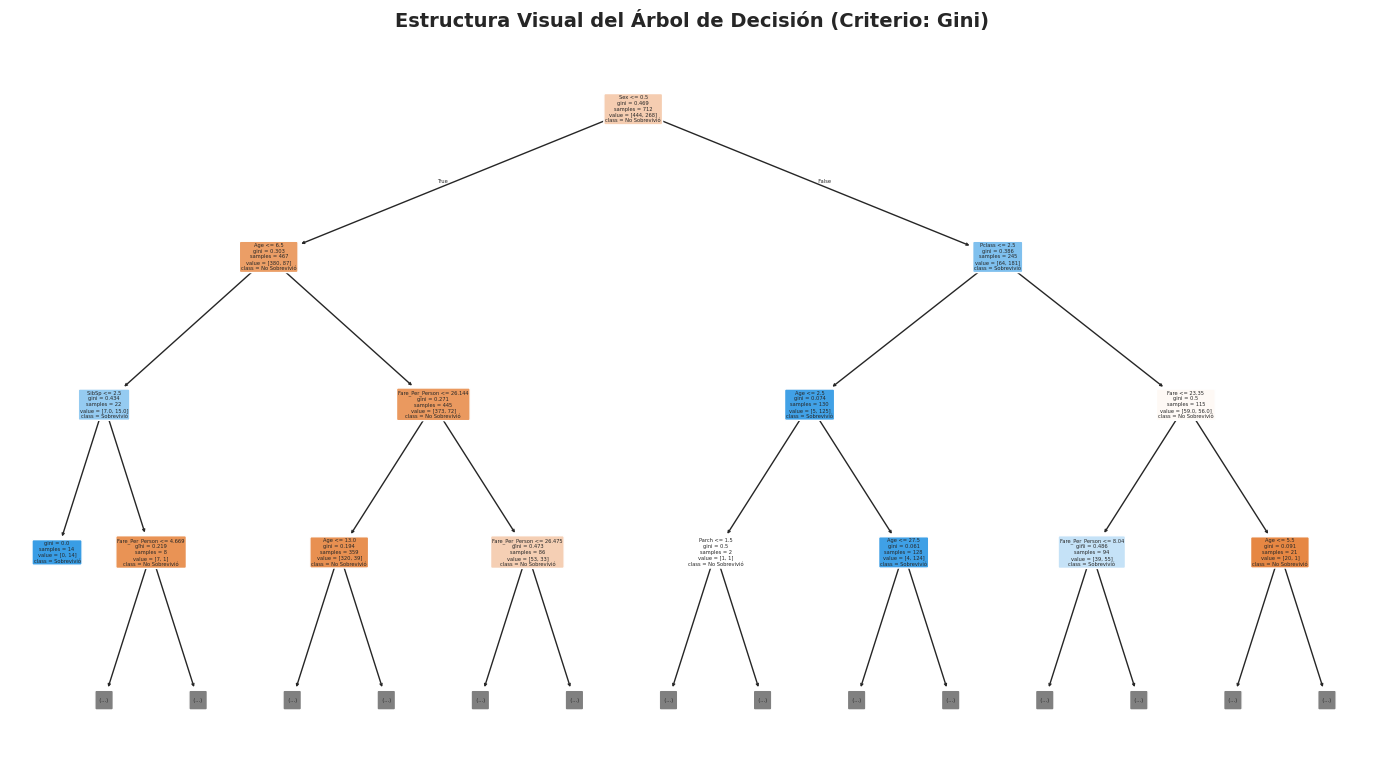

In [35]:


plt.figure(figsize=(14, 8))
plot_tree(tree_model, 
          feature_names=X.columns.tolist(), 
          class_names=['No Sobrevivió', 'Sobrevivió'], 
          filled=True, 
          rounded=True, 
          max_depth=3) # Limitamos a profundidad 3 para que sea legible en el informe
plt.title('Estructura Visual del Árbol de Decisión (Criterio: Gini)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('arbol_decision_gini.png', dpi=300)
plt.show()

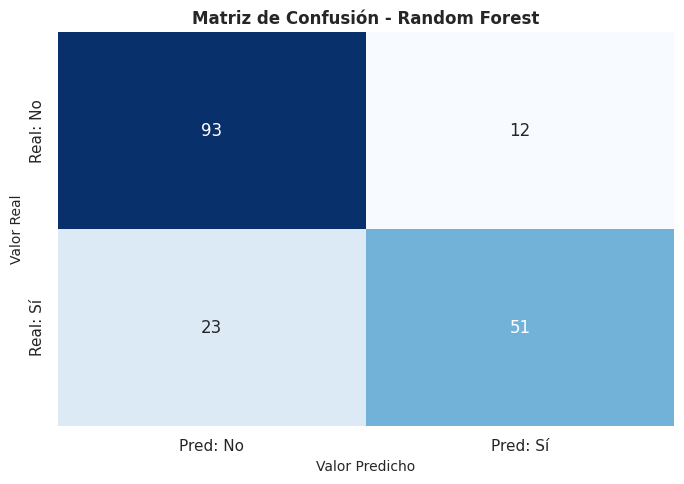

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Suponiendo que ya tienes tus etiquetas reales (y_test) y las predicciones (preds)
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Pred: No', 'Pred: Sí'], 
            yticklabels=['Real: No', 'Real: Sí'])
plt.title('Matriz de Confusión - Random Forest', fontsize=12, fontweight='bold')
plt.ylabel('Valor Real', fontsize=10)
plt.xlabel('Valor Predicho', fontsize=10)
plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=300)
plt.show()

In [37]:
#exportar los modelos entrenados desde tu notebook de Google Colab a un archivo local, la práctica recomendada en scikit-learn es utilizar la librería la libreria joblib
joblib.dump(rf_model, 'random_forest_titanic.pkl')
print("¡Modelos y scaler guardados exitosamente!")

¡Modelos y scaler guardados exitosamente!


In [38]:
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import pandas as pd

# Inicializar la aplicación de FastAPI
app = FastAPI(
    title="Titanic Survival API",
    description="API RESTful para la predicción de supervivencia en el Titanic utilizando Random Forest",
    version="1.0"
)

# Cargar el modelo entrenado previamente
model = joblib.load('random_forest_titanic.pkl')

# Definir el esquema de datos de entrada esperado con Pydantic
class PassengerInput(BaseModel):
    Pclass: int
    Sex: int  # 0: Femenino, 1: Masc
    Age: float
    SibSp: int
    Parch: int
    Fare: float
    Family_Size: int
    Fare_Per_Person: float

@app.post("/predict")
def predict_survival(data: PassengerInput):
    # Organizar los datos en un DataFrame con las características exactas
    input_df = pd.DataFrame([{
        'Pclass': data.Pclass,
        'Sex': data.Sex,
        'Age': data.Age,
        'SibSp': data.SibSp,
        'Parch': data.Parch,
        'Fare': data.Fare,
        'Family_Size': data.Family_Size,
        'Fare_Per_Person': data.Fare_Per_Person
    }])
    
    # Realizar la inferencia con el modelo de Random Forest
    prediction = int(model.predict(input_df)[0])
    probability = float(model.predict_proba(input_df)[0][1])
    
    return {
        "prediction": prediction,
        "probability": probability,
        "status": "Success",
        "message": "Sobrevivió" if prediction == 1 else "No sobrevivió"
    }

In [39]:
import streamlit as st
import requests

st.set_page_config(page_title="Titanic Predictor", page_icon="🚢", layout="centered")

st.title("🚢 Predictor de Supervivencia del Titanic")
st.write("Interfaz web interactiva conectada a tu API de FastAPI.")

st.sidebar.header("Parámetros del Pasajero")

pclass = st.sidebar.selectbox("Clase del Pasajero (Pclass)", [1, 2, 3])
sex_label = st.sidebar.selectbox("Género", ["Femenino", "Masculino"])
age = st.sidebar.slider("Edad (Años)", 0.1, 80.0, 28.0)
sibsp = st.sidebar.number_input("Hermanos / Cónyuges a bordo (SibSp)", 0, 8, 0)
parch = st.sidebar.number_input("Padres / Hijos a bordo (Parch)", 0, 6, 0)
fare = st.sidebar.number_input("Tarifa pagada (Fare)", 0.0, 500.0, 32.2)

# Mapeo exacto según tu API (Sex: 0 = Femenino, 1 = Masc)
sex = 0 if sex_label == "Femenino" else 1

# Ingeniería de características requerida por tu esquema de entrada
family_size = sibsp + parch + 1
fare_per_person = fare / family_size if family_size > 0 else fare

if st.button("Consultar API y Predecir", type="primary"):
    # Estructura del JSON que coincide exactamente con PassengerInput de tu API
    payload = {
        "Pclass": int(pclass),
        "Sex": int(sex),
        "Age": float(age),
        "SibSp": int(sibsp),
        "Parch": int(parch),
        "Fare": float(fare),
        "Family_Size": int(family_size),
        "Fare_Per_Person": float(fare_per_person)
    }
    
    # URL local de tu API (si la despliegas en la nube, reemplaza esta URL)
    api_url = "http://127.0.0.1:8000/predict"
    
    try:
        with st.spinner("Consultando la API..."):
            response = requests.post(api_url, json=payload)
        
        if response.status_code == 200:
            result = response.json()
            prediction = result["prediction"]
            probability = result["probability"]
            message = result["message"]
            
            st.subheader("Resultado de la API:")
            if prediction == 1:
                st.success(f"🎉 **¡{message}!** \n\n Probabilidad estimada: **{probability * 100:.2f}%**")
            else:
                st.error(f"⚠️ **{message}**. \n\n Probabilidad de supervivencia: **{probability * 100:.2f}%**")
        else:
            st.error(f"Error en la API. Código de estado: {response.status_code}")
            
    except requests.exceptions.ConnectionError:
        st.error("No se pudo conectar con la API. Asegúrate de tener el servidor de FastAPI ejecutándose en `http://127.0.0.1:8000`.")

ModuleNotFoundError: No module named 'streamlit'